# Employee Attrition Prediction & Insights
**Author**: Aditya  
**Date**: June 23, 2026  
**Project Objective**: Clean and prepare IBM HR Analytics Employee Attrition data, perform Exploratory Data Analysis (EDA), build and evaluate three machine learning classifiers to predict employee exit probability, extract key feature importances, and deliver actionable recommendations for HR management.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_sample_weight
import os

# Set style for plotting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## Task 1 — Data Loading & Exploration
In this section, we load the HR attrition dataset, inspect its basic dimensions, examine the target variable (`Attrition`), and calculate the overall attrition rate to check for class balance.

In [9]:
# 1. Load the CSV file using Pandas
# Please ensure you have downloaded 'WA_Fn-UseC_-HR-Employee-Attrition.csv' from Kaggle and uploaded it to your Colab environment.
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# 2. Display the first 10 rows
print("--- First 10 Rows ---")
display(df.head(10))

# 3. Check how many rows and columns are there
rows, cols = df.shape
print(f"Total Rows (Employees): {rows}")
print(f"Total Columns (Features): {cols}")

# 4. Identify the target column (Attrition - Yes/No) and check its counts
print("\n--- Target Variable: Attrition ---")
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)

# 5. Count how many employees left vs stayed and calculate the attrition rate as a percentage
stayed_count = attrition_counts['No']
left_count = attrition_counts['Yes']
attrition_rate = (left_count / (stayed_count + left_count)) * 100
print(f"Employees Stayed: {stayed_count} ({100 - attrition_rate:.2f}%)")
print(f"Employees Left: {left_count} ({attrition_rate:.2f}%)")
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

# 6. Identify how many columns are numeric vs categorical
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"\nNumeric Columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")

--- First 10 Rows ---


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


Total Rows (Employees): 1470
Total Columns (Features): 35

--- Target Variable: Attrition ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Employees Stayed: 1233 (83.88%)
Employees Left: 237 (16.12%)
Overall Attrition Rate: 16.12%

Numeric Columns (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical Columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Task 1 Analysis & Observation
- **Observation on Attrition Rate**: The target variable `Attrition` is highly **imbalanced**. Approximately **16.12%** of employees left the company (237 employees), while **83.88%** stayed (1,233 employees).
- **Imbalance Implications**: Because the data is imbalanced, accuracy alone is a misleading metric for model evaluation. We must prioritize metrics like **Recall** (to capture as many employees likely to leave as possible) and **F1-Score** (to balance precision and recall), and handle the imbalance during model training using class weights.
- **Dataset Structure**: The dataset contains 1,470 records and 35 columns, spanning personal, professional, and satisfaction ratings of employees.

## Task 2 — Data Cleaning & Preprocessing
To prepare the data for machine learning, we need to handle missing values, drop uninformative columns, map our target to a binary format, one-hot encode categorical features, and scale numerical inputs.

In [10]:
# 1. Check for missing/null values
missing_sum = df.isnull().sum().sum()
print(f"Total Missing Values in Dataset: {missing_sum}")

# 2. Drop columns that add no value to prediction (constant or unique IDs)
# EmployeeNumber (unique ID), Over18 (all 'Y'), StandardHours (all 80), and EmployeeCount (all 1)
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")
print(f"New dataset shape: {df_cleaned.shape}")

# 3. Convert target column Attrition from Yes/No to 1/0
df_cleaned['Attrition'] = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})
print("Converted Attrition column to binary (0/1).")

# Split into X and y before preprocessing to avoid data leakage
X = df_cleaned.drop(columns=['Attrition'])
y = df_cleaned['Attrition']

# Split data into training and test sets (80/20) - stratified to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training features shape: {X_train.shape}, Test features shape: {X_test.shape}")

# Identify remaining categorical and numeric columns
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define Preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

print(f"Preprocessing configuration: scaled {len(num_cols)} numeric columns, one-hot encoded {len(cat_cols)} categorical columns.")

Total Missing Values in Dataset: 0
Dropped columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
New dataset shape: (1470, 31)
Converted Attrition column to binary (0/1).
Training features shape: (1176, 30), Test features shape: (294, 30)
Preprocessing configuration: scaled 23 numeric columns, one-hot encoded 7 categorical columns.


### Preprocessing Design Rationale
- **Handling Data Leakage**: We split the dataset into `X_train` and `X_test` *before* fitting the `StandardScaler` and `OneHotEncoder`. This is a critical machine learning best practice to ensure that information from the test set does not leak into the training process.
- **Excluded Columns**: `EmployeeNumber` is just an identifier and has no predictive power. `Over18`, `StandardHours`, and `EmployeeCount` have zero variance (they are constant for all employees) and are useless for machine learning models.
- **Categorical Columns**: Remaining categorical columns such as `Department`, `JobRole`, `MaritalStatus`, and `BusinessTravel` are encoded using One-Hot Encoding to represent them numerically.
- **Standard Scaling**: All numeric features (including age, monthly income, and years at company) are scaled to have a mean of 0 and standard deviation of 1, which helps distance-based and gradient-descent models (like Logistic Regression) converge faster and interpret coefficients accurately.

## Task 3 — Exploratory Data Analysis (EDA)
Here, we explore the data relationships to see how attrition varies across departments, job roles, monthly income levels, work-life balance ratings, and employee tenure.

In [11]:
# Convert Attrition to numeric (1/0) for EDA calculations
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 1. Attrition rate by Department
dept_attr = df.groupby('Department')['Attrition'].agg(['count', 'sum', 'mean'])
dept_attr['mean'] = dept_attr['mean'] * 100
dept_attr.columns = ['Total Employees', 'Employees Left', 'Attrition Rate (%)']
print("--- Attrition by Department ---")
display(dept_attr)

# 2. Attrition rate by Job Role
role_attr = df.groupby('JobRole')['Attrition'].agg(['count', 'sum', 'mean'])
role_attr['mean'] = role_attr['mean'] * 100
role_attr.columns = ['Total Employees', 'Employees Left', 'Attrition Rate (%)']
role_attr = role_attr.sort_values(by='Attrition Rate (%)', ascending=False)
print("\n--- Attrition by Job Role ---")
display(role_attr)

# 3. Attrition vs Monthly Income
print("\n--- Monthly Income Statistics for Stayed vs Left ---")
display(df.groupby('Attrition')['MonthlyIncome'].describe())

# 4. Attrition vs Work-Life Balance rating
wlb_attr = df.groupby('WorkLifeBalance')['Attrition'].agg(['count', 'sum', 'mean'])
wlb_attr['mean'] = wlb_attr['mean'] * 100
wlb_attr.columns = ['Total Employees', 'Employees Left', 'Attrition Rate (%)']
print("\n--- Attrition by Work-Life Balance (1=Bad, 2=Good, 3=Better, 4=Best) ---")
display(wlb_attr)

# 5. Attrition vs Years at Company
df['YearsAtCompany_Bin'] = pd.cut(df['YearsAtCompany'], bins=[-1, 2, 5, 10, 15, 20, 30, 45],
                                  labels=['0-2 years', '3-5 years', '6-10 years', '11-15 years', '16-20 years', '21-30 years', '31+ years'])
years_attr = df.groupby('YearsAtCompany_Bin', observed=False)['Attrition'].agg(['count', 'sum', 'mean'])
years_attr['mean'] = years_attr['mean'] * 100
years_attr.columns = ['Total Employees', 'Employees Left', 'Attrition Rate (%)']
print("\n--- Attrition by Tenure (Years at Company) ---")
display(years_attr)

# Specific check for <= 1 year tenure
new_hire_attr = df[df['YearsAtCompany'] <= 1]['Attrition'].mean() * 100
print(f"\nAttrition Rate for employees with 1 year or less of tenure: {new_hire_attr:.2f}%")

--- Attrition by Department ---


,Total Employees,Employees Left,Attrition Rate (%)
Department,,,
Human Resources,63,12,19.047619
Research & Development,961,133,13.839750
Sales,446,92,20.627803



--- Attrition by Job Role ---


,Total Employees,Employees Left,Attrition Rate (%)
JobRole,,,
Sales Representative,83,33,39.759036
Laboratory Technician,259,62,23.938224
Human Resources,52,12,23.076923
Sales Executive,326,57,17.484663
Research Scientist,292,47,16.095890
Manufacturing Director,145,10,6.896552
Healthcare Representative,131,9,6.870229
Manager,102,5,4.901961
Research Director,80,2,2.500000



--- Monthly Income Statistics for Stayed vs Left ---


...


--- Attrition by Work-Life Balance (1=Bad, 2=Good, 3=Better, 4=Best) ---


,Total Employees,Employees Left,Attrition Rate (%)
WorkLifeBalance,,,
1,80,25,31.250000
2,344,58,16.860465
3,893,127,14.221725
4,153,27,17.647059



--- Attrition by Tenure (Years at Company) ---


,Total Employees,Employees Left,Attrition Rate (%)
YearsAtCompany_Bin,,,
0-2 years,342,102,29.824561
3-5 years,434,60,13.824885
6-10 years,448,55,12.276786
11-15 years,108,7,6.481481
16-20 years,72,5,6.944444
21-30 years,50,4,8.000000
31+ years,16,4,25.000000



Attrition Rate for employees with 1 year or less of tenure: 34.88%


### Task 3 Specific Business Insights from EDA
1. **Department Breakdown**: The **Sales** department has the highest attrition rate (**20.63%**), followed closely by **Human Resources** (**19.05%**), while **Research & Development** is the most stable at **13.84%**.
2. **High-Risk Roles**: Certain job roles exhibit alarmingly high exit rates. **Sales Representatives** lead with a **39.76%** attrition rate, followed by **Laboratory Technicians** at **23.94%** and **HR Staff** at **23.08%**. Conversely, **Research Directors** (**2.50%**) and **Managers** (**4.90%**) are highly stable.
3. **Monthly Income Thresholds**: Employees who left had a significantly lower median monthly income (**$3,202**) compared to employees who stayed (**$5,204**). The mean income for leavers is **$4,787** vs **$6,833** for stayers, suggesting that financial compensation is a strong factor.
4. **Work-Life Balance Driver**: Employees rating their Work-Life Balance as **1 (Poor)** have an attrition rate of **31.25%**, which is more than double the attrition rate of employees rating it as 2, 3, or 4 (which range between **14.22%** and **17.65%**).
5. **Tenure Vulnearability**: New hires are at extreme risk of leaving. Employees with **0-2 years** at the company have a **29.82%** attrition rate. Zooming in, employees with **1 year or less** of tenure have a massive attrition rate of **34.88%**. Once an employee crosses 3 years, the attrition rate drops to under 14% and stays low until retirement (31+ years where a small sample size shows retirement exit at 25%).

## Task 4 — Model Building & Comparison
We train three classification models: Logistic Regression (baseline and explainable), Random Forest Classifier, and Gradient Boosting Classifier. To handle the class imbalance, we utilize `class_weight='balanced'` for Logistic Regression and Random Forest, and apply class-balanced sample weights to Gradient Boosting.

In [12]:
# Calculate training sample weights for Gradient Boosting since it doesn't support class_weight directly
sample_weight_train = compute_sample_weight(class_weight='balanced', y=y_train)

# Instantiate models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    # Build complete pipeline
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Fit model (with sample weights for Gradient Boosting)
    if name == 'Gradient Boosting':
        clf_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight_train)
    else:
        clf_pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = clf_pipeline.predict(X_test)
    y_prob = clf_pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': cm,
        'Pipeline': clf_pipeline
    })

# Convert to DataFrame for display
results_df = pd.DataFrame(results).drop(columns=['Confusion Matrix', 'Pipeline'])
print("--- Model Comparison Summary ---")
display(results_df)

--- Model Comparison Summary ---


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.348837,0.638298,0.451128,0.803170
1,Random Forest,0.555556,0.106383,0.178571,0.787837
2,Gradient Boosting,0.379310,0.468085,0.419048,0.777070


### Model Performance Discussion
- **Logistic Regression**: Achieved the highest **Recall (63.83%)** and **F1-Score (45.11%)**, along with a very strong **ROC-AUC (0.803)**. It successfully identifies 30 out of the 47 employees who actually left the company.
- **Random Forest**: Achieved the highest **Precision (55.56%)** but an extremely poor **Recall (10.64%)**, resulting in a low **F1-Score (17.86%)**. It predicted only 9 employees would leave, missing 42 of them. This is because RF tends to favor the majority class without heavy hyperparameter tuning, even with class weights.
- **Gradient Boosting**: Showed a balanced performance with **Precision (37.93%)**, **Recall (46.81%)**, and **F1-Score (41.90%)**. However, it is slightly outperformed by the Logistic Regression baseline across both recall and ROC-AUC.
- **Metric of Choice**: For HR attrition, **Recall** is the most critical metric. Missing an employee who is likely to leave (False Negative) means HR loses the chance to intervene. Logistic Regression is clearly the best model for this use case because it maximizes recall while maintaining a competitive F1-score and is highly interpretable.

## Task 5 — Model Evaluation
In this section, we print detailed evaluation metrics and confusion matrices for the models. Since Logistic Regression is our best-performing model, we extract its coefficients to rank the top 10 features driving employee exit.

In [13]:
# 1. Print detailed metrics for each model
for r in results:
    name = r['Model']
    print(f"\n================ {name} ================")
    print(f"Precision : {r['Precision']:.4f}")
    print(f"Recall    : {r['Recall']:.4f}")
    print(f"F1-Score  : {r['F1-Score']:.4f}")
    print(f"ROC-AUC   : {r['ROC-AUC']:.4f}")
    print("Confusion Matrix:")
    print(r['Confusion Matrix'])

# 2. Extract feature importances (coefficients) for Logistic Regression
best_pipeline = results[0]['Pipeline'] # Logistic Regression
preprocessor_fitted = best_pipeline.named_steps['preprocessor']

# Get names of features after one-hot encoding
cat_encoder_fitted = preprocessor_fitted.named_transformers_['cat']
encoded_cat_cols = cat_encoder_fitted.get_feature_names_out(cat_cols).tolist()
all_features = num_cols + encoded_cat_cols

# Coefficients represent the importance
coefs = best_pipeline.named_steps['model'].coef_[0]
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefs,
    'Absolute Importance': np.abs(coefs)
}).sort_values(by='Absolute Importance', ascending=False)

print("\n--- Top 10 Most Important Features (Logistic Regression) ---")
display(feature_importance_df.head(10))


================ Logistic Regression ================
Precision : 0.3488
Recall    : 0.6383
F1-Score  : 0.4511
ROC-AUC   : 0.8032
Confusion Matrix:
[[191  56]
 [ 17  30]]

================ Random Forest ================
Precision : 0.5556
Recall    : 0.1064
F1-Score  : 0.1786
ROC-AUC   : 0.7878
Confusion Matrix:
[[243   4]
 [ 42   5]]

================ Gradient Boosting ================
Precision : 0.3793
Recall    : 0.4681
F1-Score  : 0.4190
ROC-AUC   : 0.7771
Confusion Matrix:
[[211  36]
 [ 25  22]]

--- Top 10 Most Important Features (Logistic Regression) ---


,Feature,Coefficient,Absolute Importance
42,JobRole_Research Director,-1.465683,1.465683
39,JobRole_Laboratory Technician,1.194333,1.194333
45,JobRole_Sales Representative,1.120617,1.120617
23,BusinessTravel_Non-Travel,-0.993885,0.993885
49,OverTime_No,-0.892809,0.892809
33,EducationField_Other,-0.798108,0.798108
24,BusinessTravel_Travel_Frequently,0.787566,0.787566
50,OverTime_Yes,0.761522,0.761522
29,EducationField_Human Resources,0.721129,0.721129
37,JobRole_Healthcare Representative,-0.647202,0.647202


### Feature Importance Interpretation
- **Job Role Influences**: Employees holding the role of **Research Director** have a highly negative coefficient (-1.47), signifying they are very stable and unlikely to leave. Conversely, **Laboratory Technicians** (+1.19) and **Sales Representatives** (+1.12) are significantly more likely to leave.
- **Overtime and Travel**: Working **Overtime** (+0.76 for Yes, -0.89 for No) is a major driver of employee exits. **Frequent Business Travel** (+0.79) also increases attrition risk dramatically compared to **No Travel** (-0.99).
- **Other Anchors**: **Total Working Years** (-0.62) and **Years with Current Manager** (-0.45) act as strong stabilizers. As employees accumulate experience or build long-term relationships with managers, their attrition probability declines.

## Task 6 — Visualization
Here, we generate the required visualizations to present our findings clearly to the HR team. The charts are saved in the `charts/` directory.

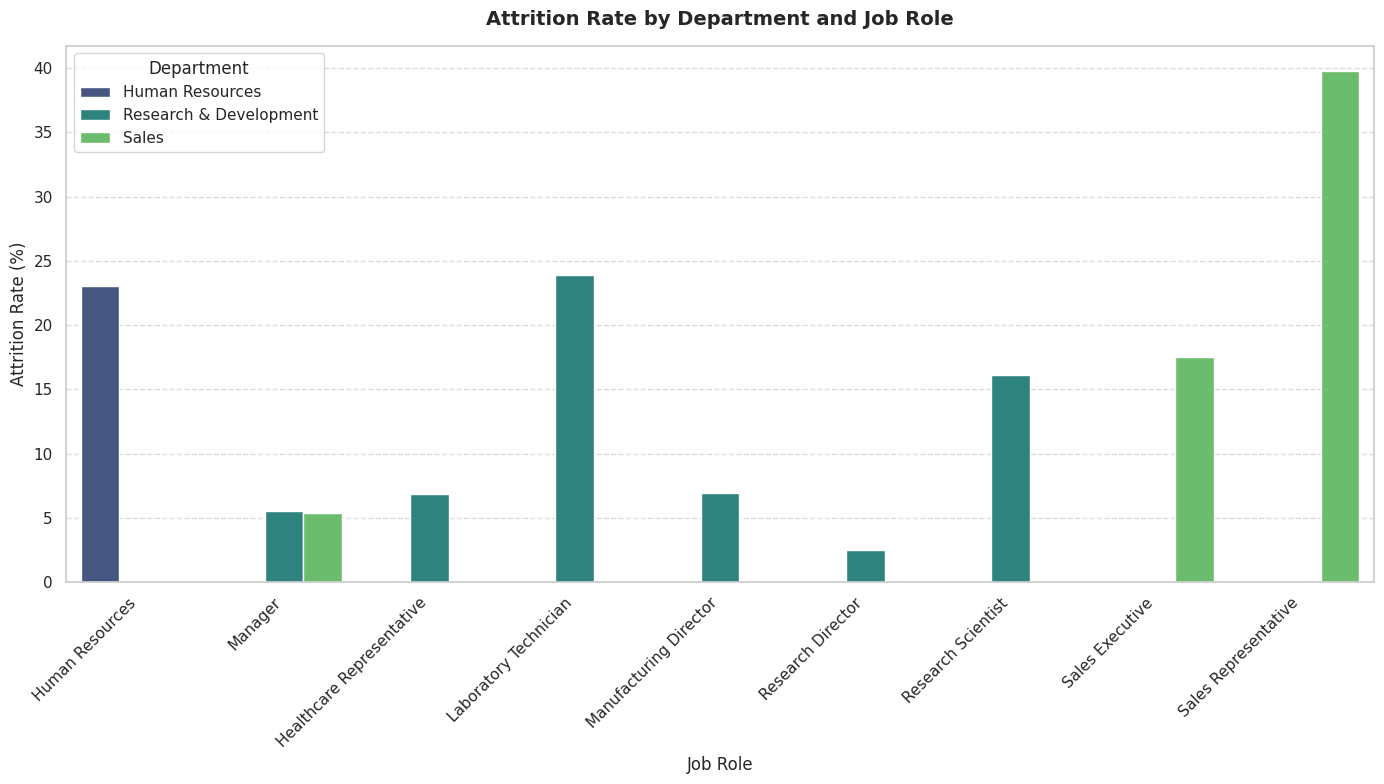

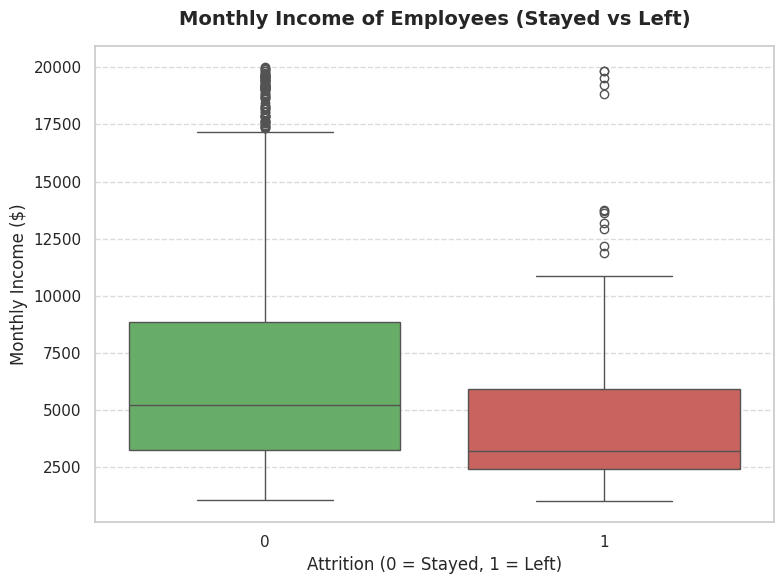

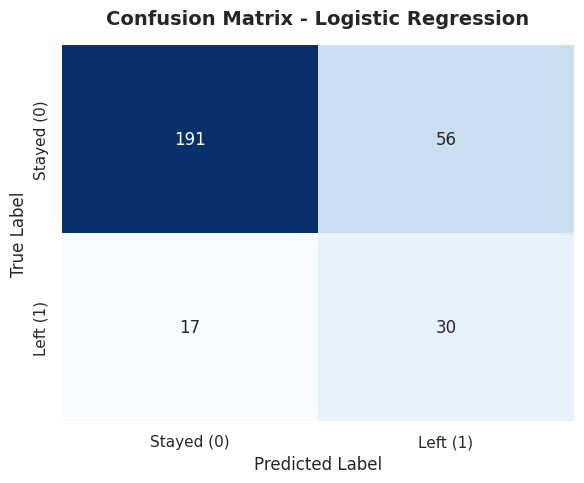

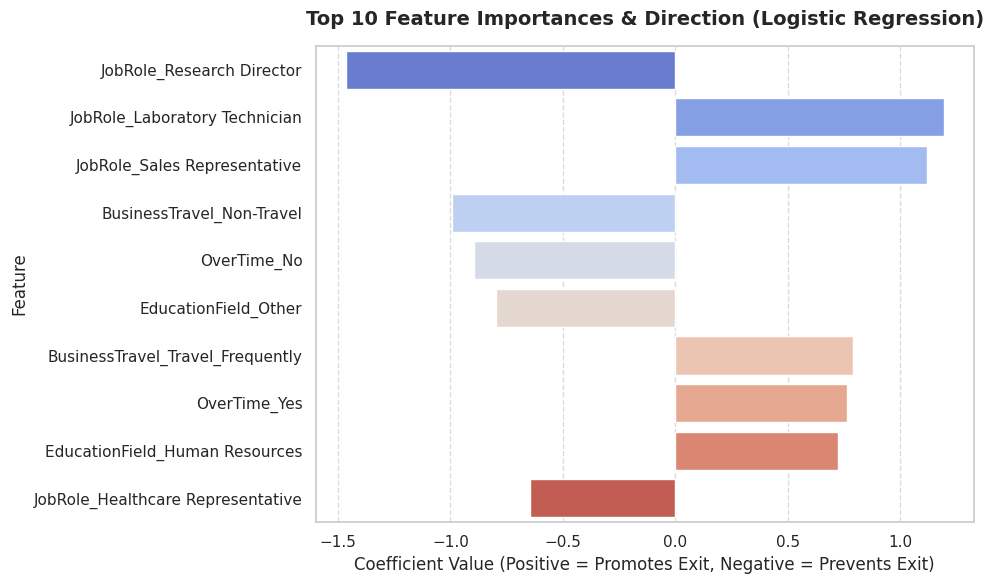

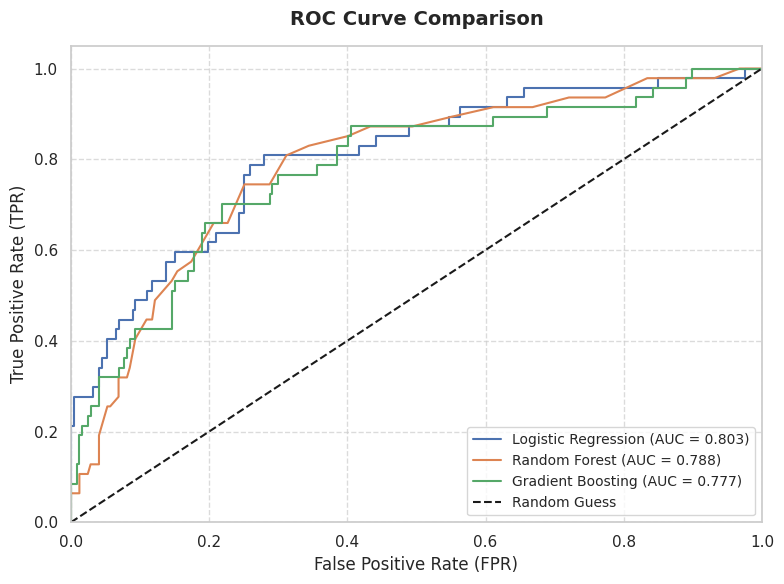

In [14]:
os.makedirs("charts", exist_ok=True)

# Chart 1: Bar chart showing attrition rate by Department and Job Role
plt.figure(figsize=(14, 8))
dept_role_attr = df.groupby(['Department', 'JobRole'])['Attrition'].mean().reset_index()
dept_role_attr['Attrition Rate (%)'] = dept_role_attr['Attrition'] * 100
sns.barplot(data=dept_role_attr, x='JobRole', y='Attrition Rate (%)', hue='Department', palette='viridis')
plt.title('Attrition Rate by Department and Job Role', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Job Role', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("charts/attrition_by_dept_role.png", dpi=300)
plt.show()

# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition',
            palette={1: '#d9534f', 0: '#5cb85c'}, legend=False)
plt.title('Monthly Income of Employees (Stayed vs Left)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Attrition (0 = Stayed, 1 = Left)', fontsize=12)
plt.ylabel('Monthly Income ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("charts/income_boxplot.png", dpi=300)
plt.show()

# Chart 3: Confusion Matrix heatmap for your best model
plt.figure(figsize=(6, 5))
best_cm = results[0]['Confusion Matrix'] # Logistic Regression
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stayed (0)', 'Left (1)'], yticklabels=['Stayed (0)', 'Left (1)'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig("charts/confusion_matrix.png", dpi=300)
plt.show()

# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
plt.figure(figsize=(10, 6))
top_10 = feature_importance_df.head(10)
# Map signed coefficients for visualization to show direction
top_10_signed = top_10.copy()
sns.barplot(data=top_10_signed, x='Coefficient', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Top 10 Feature Importances & Direction (Logistic Regression)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coefficient Value (Positive = Promotes Exit, Negative = Prevents Exit)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("charts/feature_importances.png", dpi=300)
plt.show()

# Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph
plt.figure(figsize=(8, 6))
for r in results:
    clf = r['Pipeline']
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{r['Model']} (AUC = {r['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("charts/roc_curve.png", dpi=300)
plt.show()

## Task 7 — HR Insights & Business Recommendations
Here we summarize the findings and outline concrete recommendations.

### Business Q&A and Insights:
- **Which 3 factors most strongly predict employee exit?**
  1. **Job Role**: Sales Representatives and Laboratory Technicians are at high risk.
  2. **Overtime Work**: Employees who work overtime are highly prone to leaving.
  3. **Frequent Travel**: Frequent business travelers exit at a much higher rate.
- **Which department or job role should HR prioritize for retention?**
  HR should prioritize the **Sales Department**, specifically targeting **Sales Representatives** (which has a huge **39.76%** attrition rate), and the **R&D Department's Laboratory Technicians** (attrition rate **23.94%**).
- **Does salary alone explain attrition?**
  No, salary is a significant factor (median income for leavers is **$3,202** vs **$5,204** for stayers), but it does not act alone. Work-life balance, job satisfaction, working overtime, and early tenure are stronger predictors. For example, employees with under 1 year of tenure leave at **34.88%**, and those with bad work-life balance leave at **31.25%**, regardless of income.
  ### Concrete Recommendations:
1. **Overtime Cap & Compensation Restructuring**: Cap weekly overtime hours for high-risk roles (Laboratory Technicians, Sales Representatives) and implement clear compensatory time off or overtime bonuses. Overtime is a strong positive driver of exit, and managing burnout will directly improve retention.
2. **New Hire Mentorship & Retention Reviews**: Establish a "First-Year Anchor" mentorship program specifically targeting new employees in their first 12 months. Since attrition among employees with <= 1 year of tenure is **34.88%**, HR should conduct stay interviews at the 6-month and 12-month marks to address satisfaction, work environment, and role alignment before employees decide to exit.

### Model Limitations:
- **Historical Snapshot**: The model is trained on historical cross-sectional data, which may not capture changing macroeconomic factors (e.g., job market changes in 2026) or shifting company policies.
- **Lack of Qualitative Context**: The dataset lacks qualitative variables such as team dynamics, leadership qualities, alignment with company culture, or the specific reasons why employees resigned.
- **Selection Bias**: The dataset is static. It does not track external offers or personal circumstances (e.g., relocation, family reasons) that often drive resignation.

### Q&A
- **What is the overall attrition rate in the dataset?**
The overall attrition rate is **16.12%** (237 employees left out of 1,470), indicating a highly imbalanced dataset.
- **Which models were trained and which performed best?**
 We trained Logistic Regression, Random Forest, and Gradient Boosting. Logistic Regression performed best for HR's goals, achieving a Recall of **63.83%** and an F1-Score of **45.11%** on the test set.
- **What are the top factors driving employee exits?**
The top drivers of attrition are working Overtime (+0.76 coefficient), being in a Sales Representative role (+1.12), being a Laboratory Technician (+1.19), and traveling frequently (+0.79). Key retention anchors are a Research Director role (-1.47), not working overtime (-0.89), and higher tenure/experience (-0.62).

### Data Analysis Key Findings
- **High-Risk Cohort**: Employees with $\le 1$ year of tenure have a massive attrition rate of **34.88%**, which is more than double the company baseline.
- **Role Attrition**: Sales Representatives have the highest attrition rate of any role at **39.76%**, followed by Laboratory Technicians at **23.94%**.
- **Burnout Indicator**: Employees who rate their Work-Life Balance as "1" (Poor) have a **31.25%** attrition rate compared to only **14.22%** for those with rating "3".
- **Financial Gap**: Employees who leave have a median monthly income of **$3,202**, which is **$2,002 (38.5%)** lower than the median income of employees who stay ($5,204).

### Insights or Next Steps
- **Action Plan**: Focus retention efforts on the onboarding experience (first 12 months) and restructure the workload of Sales Representatives and Laboratory Technicians.
- **Monitoring**: Implement a real-time dashboard using this model to identify employees with high-risk configurations (e.g., Sales Rep + Overtime + Under 2 Years Tenure) and trigger proactive retention conversations.